# 📊 Sales & Demand Forecasting using Machine Learning
### Future Interns – ML Task 1

This project predicts future sales using historical sales data and machine learning techniques.

## 🎯 Project Goal
The objective of this project is to analyze past sales trends and build a machine learning model that can forecast future demand. Such forecasting helps businesses plan inventory, staffing, and financial decisions.

## ⚙️ Install Required Libraries

This section installs the Python libraries required for the project, including pandas, numpy, matplotlib, and scikit-learn.

In [2]:
pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📚 Import Libraries

These libraries are used for data manipulation, visualization, and machine learning model development.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


## 📂 Load Dataset

The dataset containing historical monthly sales data is loaded using pandas.

In [5]:
data = pd.read_csv("sales.csv")

data.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


## 🔍 Explore Dataset

This step checks the structure of the dataset, including column types and number of records.

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Month   108 non-null    str  
 1   Sales   108 non-null    int64
dtypes: int64(1), str(1)
memory usage: 1.8 KB


## 🧹 Data Preprocessing

The Month column is converted into datetime format so it can be used for time-based analysis.

In [7]:
data['Month'] = pd.to_datetime(data['Month'])
data.head()

,Month,Sales
0,1960-01-01,6550
1,1960-02-01,8728
2,1960-03-01,12026
3,1960-04-01,14395
4,1960-05-01,14587


## 📈 Sales Trend Visualization

This graph shows how sales change over time and helps identify patterns and trends in the dataset.

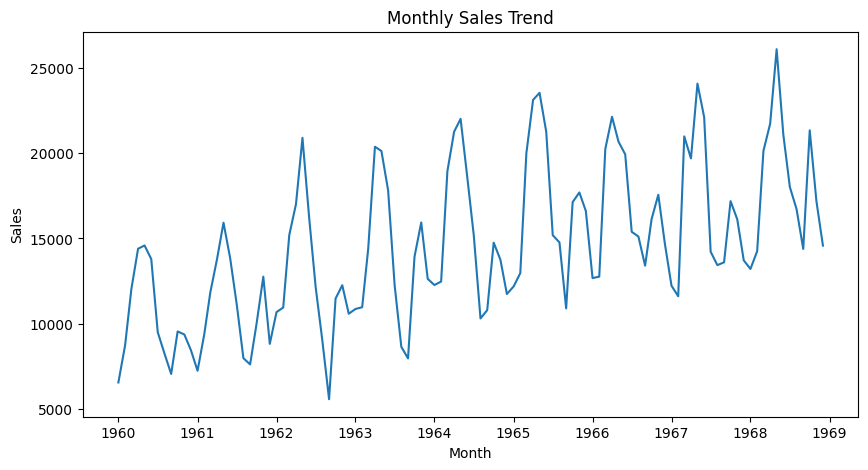

In [8]:
plt.figure(figsize=(10,5))
plt.plot(data['Month'], data['Sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## ⚙️ Feature Engineering

New features such as Year and Month number are extracted from the date column to help the machine learning model learn time patterns.

In [9]:
data['Year'] = data['Month'].dt.year
data['Month_num'] = data['Month'].dt.month

data.head()

,Month,Sales,Year,Month_num
0,1960-01-01,6550,1960,1
1,1960-02-01,8728,1960,2
2,1960-03-01,12026,1960,3
3,1960-04-01,14395,1960,4
4,1960-05-01,14587,1960,5


## 🎯 Define Features and Target

The dataset is split into input features (Year and Month) and the target variable (Sales).

In [10]:
X = data[['Year','Month_num']]
y = data['Sales']

## 🔀 Train-Test Split

The dataset is divided into training and testing sets so the model can be evaluated on unseen data.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## 🤖 Model Training

A Linear Regression model is trained using the training dataset.

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 🔮 Model Predictions

The trained model predicts sales values using the test dataset.

In [14]:
predictions = model.predict(X_test)

predictions[:5]

array([13791.95349732, 14479.45349101, 16861.37331695, 13062.86062731,
       12785.03365876])

## 📉 Model Evaluation

The Mean Absolute Error (MAE) metric is used to evaluate how accurate the model predictions are.

In [15]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, predictions)

print("Model Error:", error)

Model Error: 3435.146117521958


## 📊 Actual vs Predicted Sales

This visualization compares the predicted sales values with the actual sales values to evaluate the model's performance.

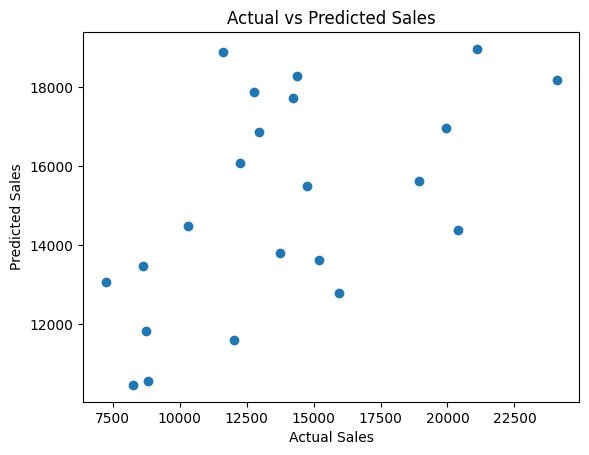

In [16]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

## 🚀 Future Sales Prediction

The trained model is used to predict future sales based on the given year and month.

In [18]:
future = pd.DataFrame({
    'Year':[2026],
    'Month_num':[1]
})

future_prediction = model.predict(future)

print("Predicted Sales for Jan 2026:", future_prediction)

Predicted Sales for Jan 2026: [78512.65013324]


## 📊 Actual vs Predicted Sales

This visualization compares the **actual sales values** from the test dataset with the **sales values predicted by the machine learning model**.

Each blue point represents a data sample.  
- **X-axis:** Actual Sales  
- **Y-axis:** Predicted Sales  

The **red dashed diagonal line** represents the line of perfect predictions (where predicted values equal actual values).

Points that lie **close to the red line** indicate accurate predictions, while points farther from the line show prediction error.

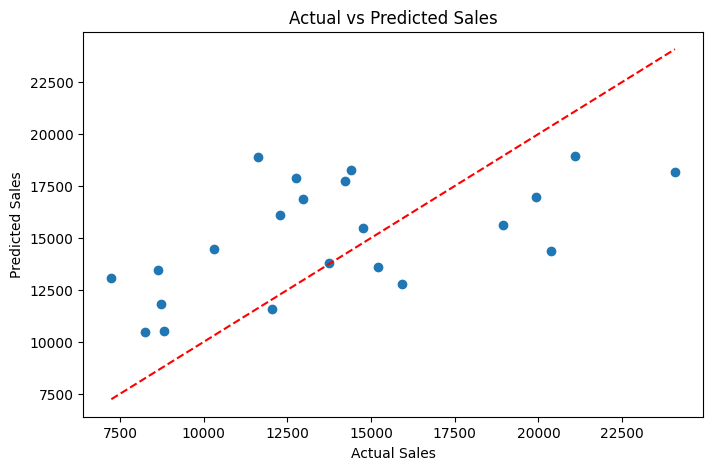

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

## ✅ Conclusion

This project demonstrates how machine learning can be used to forecast future sales using historical data. Such models help businesses make better decisions in areas such as inventory planning, staffing, and demand forecasting.